# Phys 501 Final Project - Practical Implementation of Fourier-Bessel Series

# Andrew Koren



Since the preliminaries section is primarily content we've already covered in class, I've skipped through some of the derivations we've already worked through. They provide important background before we discuss the continuous Hankel transform, so I couldn't remove the section entirely.

---
 Preliminaries
---

In class, Bessel Functions have primarily appeared as solutions to differential equations in polar or cylindrical coordinates. In cylindrical coordinates, the Laplace equation $\nabla^2 u = 0 $ and simliar problems (heat equation, wave equation, etc.) often produce the Bessel Differential Equation

$$
r^2 R''(r) + r R'(r) + (k^2r^2 - n^2)R(r) = 0
$$

where $n$ groups together the separate solutions not dependent on $r$ [1]. This is solved by the Bessel functions $J_n(k r)$ and $Y_n(k r)$, with weight and order $n$ depending on the boundary conditions used. 

One key feature of Bessel functions is their orthogonality, which allows for a variety of boundaries and initial conditions to be represented. According to Sturm-Lioville theory, putting the Bessel Differential Equation in Self-adjoint form will allow us to define a scalar product with eigenfunctions as solutions to the ODE [2]. If this is the case, each eigenfunction which corresponds to a different eigenvalue will be orthogonal according to the scalar product, allowing us to expand various functions within the domain of the solution in terms of Bessel Functions. 

In class, we derived the self-adjoint form by dividing the ODE by $r$ and found the weight function $w(r) = r$ as

$$
\\  r R''(r) + R'(r) + \left(k^2 r - {n^2 \over r}\right) R(r) = 0
\\  (p(r)R'(r))' + \left(\lambda w(r) - q(r)\right) R(r) = 0
\\  p(r) = r
\qquad
    \lambda = k^2
\qquad
    w(r) = r
\qquad q(r) = {n^2 \over r},
$$

yielding the scalar product as

$$
\langle f, g \rangle = \int_{a}^{b} f^*(r) g(r) r dr.
$$

Interestingly, while any bessel function $J_n(kr)$ is an eigenfunction of $\mathcal L_n(r) = {d \over dr}\left(r {d \over dr} \right) + \left(\lambda r - {n^2 \over r} \right)$, the scalar product yields an orthogonality condition on the domain $(0,1]$ specifically when $k$ is a zero of the eigenfunction $J_n(x_{n,k})=0$:

$$ 
      \langle J_{n}(x_{n,k}x), J_{n}(x_{n,k'}x) \rangle
    = \int_0^1 J_{n}(x_{n,k}x) J_{n}(x_{n,k'}) x dx 
    = {\delta_{kk'} \over 2} J^2_{n+1}(x_{n,k}).
$$
Or, rescaled to the domain $(0, r_{\text{max}}]$ with $x \rightarrow r/r_{\text{max}}$:
$$
    \alpha_{n,k} = {x_{n,k} \over r_{\text{max}}}    
\\  J_n(\alpha_{n,k}r_{\text{max}}) = 0
\\  \langle J_{n}(\alpha_{n,k}r), J_{n}(\alpha_{n,k'}r) \rangle  
    = {\delta_{kk'} r_{\text{max}}^2 \over 2} J^2_{n+1}(\alpha_{n,k}).
$$

As we've seen in class, it is this orthogonality which allows us to expand any "good" function in the Hilbert space of this scalar product, and we used this to solve various differential equations. However, this project is less focused on solving differential equations and is more interested in understanding these expansions. We will be going in-depth on what kinds of signals/distributions can be accurately recreated by Bessel functions, as well as look at a _continuous_ expansion in the form of the Hankel Transform.


<!-- Interestingly, the Bessel functions are eigenfunctions on the domain $[0,1]$ only when $k$ corresponds to a zero of a Bessel function $k = x_{n,k}$, with eigenvalue $\lambda = k^2 = x_{n,k}^2$

$$
    J_n(x_{n,k}) = 0
\\  \mathcal L_n(r) = {d \over dr}\left(r {d \over dr} \right) + \left(\lambda r - {n^2 \over r} \right)
\\  \mathcal L_n(x) J_n(x_{n,k} x) = x_{n,k}^2 J_n(x_{n,k} x)
$$ -->

---
 Fourier-Bessel expansion and Hankel Transform
---

Including the orthogonality of the Fourier expansion, any function $f(r,\theta)$ can be expanded into the Fourier-Bessel series as

$$
    f(r,\theta) = \sum_{m=-\infty}^\infty \sum_{k=1}^\infty c_{m,k} J_n(\alpha_{n,k}r)e^{im\theta}
\\  c_{m,k} 
    = \left\langle
      \frac{\left\langle f(r,\theta), e^{im\theta} \right\rangle}
           {\left\| e^{im\theta} \right\|^2},
      J_n(\alpha_{n,k}r)
      \right\rangle \Big/ \left\| J_n(\alpha_{n,k} r) \right\|^2 

\\  = {1 \over \pi r_{\text{max}^2 J_{n+1}^2 (\alpha_{n,k})}} \int_0^{r_{\text{max}}} \int_0^{2\pi} f(r,\theta) e^{-im \theta} J_n(\alpha_{n,k r})r d\theta dr
$$

Note however, that this isn't the textbook definition of the expansion. Can you see what's off? Our textbook expansion defines the order of the bessel function as $n=|m|$, but this isn't strictly necessary for convergence. In the book, the choice $n=|m|$ is obvious since the seperable solution $\psi = R(r)\Theta(\theta)$ to the Laplace equation or other PDEs forces the Bessel differential equation to have $n$ be the same as an angular mode number. Sturm-Lioville theory doesn't directly force $n=|m|$. 

We can show an example of this by reconstructing a simple function, like $f(r,\theta) = r(1-r) \cos \theta$, and a simple visual inspection should show this works. I've moved the majority of the code to a separate module `finalproj.py` for clarity

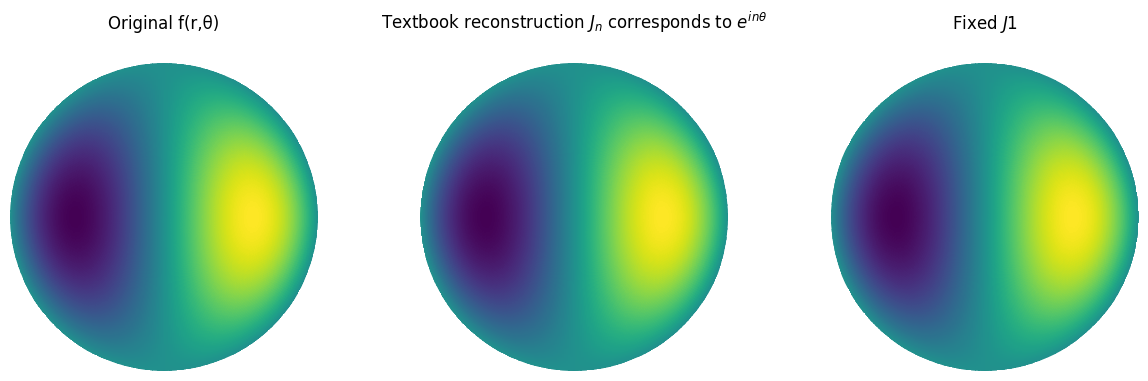

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.00250625, 0.00250594, 0.00250501, ..., 0.00250501, 0.00250594,
         0.00250625],
        [0.00501241, 0.00501178, 0.00500992, ..., 0.00500992, 0.00501178,
         0.00501241],
        ...,
        [0.00994981, 0.00994858, 0.00994488, ..., 0.00994488, 0.00994858,
         0.00994981],
        [0.0049937 , 0.00499308, 0.00499123, ..., 0.00499123, 0.00499308,
         0.0049937 ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(400, 400)),
 array([[-3.77980321e-13+0.00000000e+00j, -3.77980321e-13+0.00000000e+00j,
         -3.77980321e-13+0.00000000e+00j, ...,
         -3.77980321e-13+0.00000000e+00j, -3.77980321e-13+0.00000000e+00j,
         -3.77980321e-13+0.00000000e+00j],
        [ 2.44250174e-03+8.94597273e-12j,  2.44219890e-03+3.84613041e-05j,
          2.44129046e-03+7.69130618e-05j, ...,
          2.44129046e-03-7.69

In [5]:
import numpy as np
from finalproj import naive_f_expansion, recon_f_from_naive, plot_3_spheres
import matplotlib.pyplot as plt

def f(r, theta, R):
    return r*(1-r*r)*np.cos(theta)

# parameters
R = 1.0
Nr, Ntheta = 400, 400
N, M = 10, 10 # angular, radial modes
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
fixed_order = 1

plot_3_spheres(f, R, Nr, Ntheta, N, M, fixed_order)



According to my preferred method of quantifying error, the eyeball method, it looks like using a fixed order $n=1$ has a bit of trouble recreating the function, while the textbook method has no issues. Surely higher order bessel functions won't struggle more. Let's try $J_{19}(r/r_{\text{max}})$

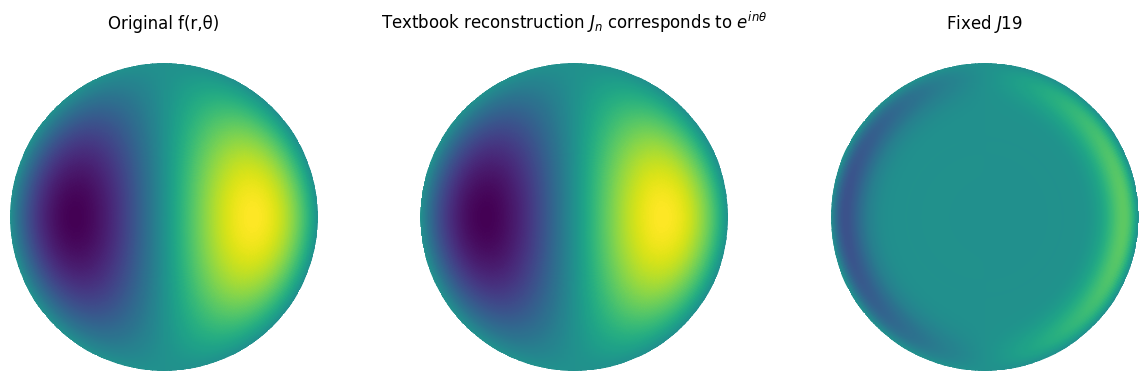

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.00250625, 0.00250594, 0.00250501, ..., 0.00250501, 0.00250594,
         0.00250625],
        [0.00501241, 0.00501178, 0.00500992, ..., 0.00500992, 0.00501178,
         0.00501241],
        ...,
        [0.00994981, 0.00994858, 0.00994488, ..., 0.00994488, 0.00994858,
         0.00994981],
        [0.0049937 , 0.00499308, 0.00499123, ..., 0.00499123, 0.00499308,
         0.0049937 ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(400, 400)),
 array([[-3.77980321e-13+0.00000000e+00j, -3.77980321e-13+0.00000000e+00j,
         -3.77980321e-13+0.00000000e+00j, ...,
         -3.77980321e-13+0.00000000e+00j, -3.77980321e-13+0.00000000e+00j,
         -3.77980321e-13+0.00000000e+00j],
        [ 2.44250174e-03+8.94597273e-12j,  2.44219890e-03+3.84613041e-05j,
          2.44129046e-03+7.69130618e-05j, ...,
          2.44129046e-03-7.69

In [7]:
# parameters
R = 1.0
Nr, Ntheta = 400, 400
N, M = 10, 10 # angular, radial modes
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
fixed_order = 19

plot_3_spheres(f, R, Nr, Ntheta, N, M, fixed_order)

That looks a bit further off. In reality, Bessel function order in the Bessel-Fourier series goes deeper than solutions to differential equations. I've had trouble finding a textbook which doesn't argue that this comes from an eigenvalue problem, but the well-developed discussion around Fourier series and Fourier transforms does give us some insight.

$$

$$

---
 Quasispectral Discrete Hankel Transform
---

In truth, this whole demonstration is cleverly selected

Unlike various polynomial series, the bessel function series is orthogonal on the domain $[0,1]$, allowing it to define radial functions of finite size. This makes sense for discussing vibrating drums, but functions which decay to zero at infinity are off the table. This is actually a great feature for signal processing, since it should help prot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from PIL import Image
from finalproj import FourierBesselTransform

# ... (Include the FourierBesselTransform and DHT classes from the previous step) ...

def sample_image_on_polar_grid(img_arr, solver):
    """
    Maps a cartesian image onto the solver's (N_theta, 2*N_radial) grid.
    """
    h, w = img_arr.shape
    cy, cx = h / 2, w / 2
    max_radius_pix = min(h, w) / 2

    # 1. Get solver grid (Normalized r=[0,1])
    # solver.R and solver.TH are shape (N_theta, 2*Nr)
    R_grid = solver.R
    TH_grid = solver.TH

    # 2. Convert Polar (0..1) -> Cartesian (pixels)
    # x = r * cos(theta), y = r * sin(theta)
    # We map r=1 to the edge of the image (max_radius_pix)
    X_polar = R_grid * np.cos(TH_grid) * max_radius_pix + cx
    Y_polar = R_grid * np.sin(TH_grid) * max_radius_pix + cy

    # 3. Interpolate
    # map_coordinates expects shape (2, N_points), so we flatten and reshape
    coords = np.vstack((Y_polar.flatten(), X_polar.flatten()))
    
    # order=3 is cubic spline (high quality), order=1 is linear
    sampled_flat = map_coordinates(img_arr, coords, order=3, mode='constant', cval=0.0)
    sampled_polar = sampled_flat.reshape(R_grid.shape)
    
    # Mask out corners (where r > 1, though grid logic usually handles this, 
    # the square image might have corners outside the circle)
    sampled_polar[R_grid > 1.0] = 0
    
    return sampled_polar

# --- Main Execution ---

# 1. Load Image
# Ensure you have the image or replace with a generated one
try:
    img = Image.open('Friedrich_Wilhelm_Bessel_(1839_painting).png').convert('L')
    img_arr = np.asarray(img).astype(float) / 255.0  # Normalize 0-1
except FileNotFoundError:
    print("Image not found, generating a dummy test pattern.")
    x = np.linspace(-1, 1, 512)
    X, Y = np.meshgrid(x, x)
    img_arr = np.exp(-(X**2 + Y**2)/0.5) * np.cos(10*X) * np.cos(10*Y) # Checkerboard-ish Gaussian

# 2. Setup Solver
# Heuristic: Nr = Image Width // 4. 
# For a 500px image -> Nr=125. 
img_dim = min(img_arr.shape)
Nr = int(img_dim // 4)  
Nth = int(Nr * 4)       # Compromise between perfect resolution and speed

print(f"Image Dim: {img_dim}px. Using Radial Modes: {Nr}, Azimuthal Modes: {Nth}")
solver = FourierBesselTransform(Nr=Nr, Nth=Nth)

# 3. Sample Image -> Polar Grid
print("Sampling image to polar coordinates...")
polar_image = sample_image_on_polar_grid(img_arr, solver)

# 4. Forward Transform (Analysis)
print("Performing Forward FB Transform...")
coeffs = solver.phys_to_spec(polar_image)

# 5. Backward Transform (Synthesis)
print("Performing Inverse FB Transform...")
reconstructed_polar = solver.spec_to_phys(coeffs)

# --- Visualization ---

# Take real part for visualization
rec_real = reconstructed_polar.real

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# --- ROW 0: Spatial Domain ---

# 1. Original Cartesian
ax[0, 0].imshow(img_arr, cmap='gray')
ax[0, 0].set_title("Original Image (Cartesian)")
ax[0, 0].axis('off')

# 2. Polar Input (Unwrapped)
# This shows exactly what the FFT sees: a rectangular grid of r vs theta
ax[1, 0].imshow(polar_image.T, cmap='gray', aspect='auto')
ax[1, 0].set_ylabel('Radius (j)')
ax[1, 0].set_xlabel('Theta (q)')
ax[1, 0].set_title("Unwrapped Input (Polar Domain)")

# 3. Reconstructed (Unwrapped)
ax[0, 2].imshow(rec_real.T, cmap='gray', aspect='auto')
ax[0, 2].set_title("Unwrapped Reconstruction")
ax[0, 2].set_xlabel('Theta (q)')


# --- ROW 1: Spectral Domain & Projection ---

# Shift coefficients so q=0 is in the center of the x-axis
coeffs_shifted = np.fft.fftshift(coeffs, axes=0)
extent = [-Nth//2, Nth//2, Nr, 0] # q from -N/2 to N/2, r from 0 to N

# 4. Spectrum Amplitude (Log Scale)
# We use log1p to make details visible, otherwise only DC (0,0) is bright
spec_mag = np.log1p(np.abs(coeffs_shifted))

# Clip contrast to 99th percentile to prevent the DC component from washing out details
vmax = np.percentile(spec_mag, 99.5) 

im_mag = ax[1, 0].imshow(spec_mag.T, cmap='inferno', aspect='auto', 
                         extent=extent, vmax=vmax)
ax[1, 1].set_title(r"Spectrum Amplitude $\log(1+|F|)$")
ax[1, 1].set_xlabel("Azimuthal Mode (q)")
ax[1, 1].set_ylabel("Radial Mode (j)")
plt.colorbar(im_mag, ax=ax[1, 0], fraction=0.046, pad=0.04)

# 5. Spectrum Phase
spec_phase = np.angle(coeffs_shifted)
im_phase = ax[1, 1].imshow(spec_phase.T, cmap='twilight', aspect='auto', 
                           extent=extent, vmin=-np.pi, vmax=np.pi)
ax[0, 1].set_title("Spectrum Phase (rad)")
ax[0, 1].set_xlabel("Azimuthal Mode (q)")
ax[0, 1].set_yticks([]) # Hide y-axis as it's same as left plot
plt.colorbar(im_phase, ax=ax[1, 1], fraction=0.046, pad=0.04)

# 6. Polar Projection (The Fixed [1,2] Plot)
# We remove the old [1,2] difference plot and move the projection here.
ax[1, 2].remove() # Clean up the standard axes
ax[1, 2] = fig.add_subplot(2, 3, 6, projection='polar')

r_grid = solver.r_uniform
th_grid = solver.th_uniform
R_mesh, TH_mesh = np.meshgrid(r_grid, th_grid)

# Plot
ax[1, 2].pcolormesh(TH_mesh, R_mesh, rec_real, cmap='gray', shading='auto')

# FIX ORIENTATION
# 1. Set theta direction to Clockwise (-1) to match image coordinate y-axis (down)
ax[1, 2].set_theta_direction(-1)
# 2. Set zero location to East (Standard image x-axis starts at right)
ax[1, 2].set_theta_zero_location("E")

ax[1, 2].set_title("Reconstruction Projected")
ax[1, 2].set_axis_off()

plt.tight_layout()
plt.show()


Image Dim: 190px. Using Radial Modes: 47, Azimuthal Modes: 188


<br> [1]: Pinsky $\S$ 3.2
<br> [2]: Arfken Weber $\S$ 8.2

Sources
- [An improved method for computing a discrete Hankel transform](https://www.sciencedirect.com/science/article/pii/0010465587902049)

Sources

- https://mathworld.wolfram.com/Fourier-BesselSeries.html
- https://en.wikipedia.org/wiki/Bessel_function 
- https://users.math.msu.edu/users/gnagy/teaching/ode-2ed.pdf
- Arfken Weber
- https://arxiv.org/pdf/2005.06076
- https://en.wikipedia.org/wiki/Non-uniform_discrete_Fourier_transform